# Toxic Comments Classification - NB

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JgsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: NB

Preprocessing techniques used:
* Lowercase
* Remove rare words
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set2.csv')
df.head()

,Unnamed: 0,tweet,tox
0,12478,Just straight like that. No chaser. And the bi...,1
1,5791,@blowme you mean trash.,0
2,589,"""WHAAAAAAT! LMAOOO!!! @Cromotoasted: @creepgod...",1
3,18302,RT @Tylar____: Man this hoe Heaven stay taking...,1
4,8736,"Col. Sanders, Part 2: ""...and those sons of bi...",1


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set2.csv')
test.head()

,Unnamed: 0,tweet,tox
0,24082,auto tranny,0
1,10605,I get gwop now that bitch remember me,1
2,15645,RT @FunnyPicsDepot: Niggas develop superpowers...,1
3,6551,@kaylonnnnn then who are you to call me trash ...,0
4,14482,RT @AliAbunimah: The people of the ghetto are ...,0


# 3. Preprocessing

In [4]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
       
    return comment

In [5]:
# clean and normalize comments
df['tweet'] = df['tweet'].map(lambda word:clean_text(word))
test['tweet'] = test['tweet'].map(lambda word:clean_text(word))

In [6]:
# find the 10 most frequent words in train date
dellist1 = pd.Series(' '.join(df['tweet']).split()).value_counts(ascending=True)[1:10]
print(dellist1)

"@__sneakyb:              1
trevaughn3                1
....thank                 1
baddest,                  1
retard...should           1
@_rinko0                  1
http://t.co/0dvazwlq2q    1
http://t.co/sahge1wgas    1
revaluate                 1
dtype: int64


In [7]:
# remove the most frequent word from the train data
dellist1 = list(dellist1.index)
df['tweet'] = df['tweet'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist1))
df.head()

,Unnamed: 0,tweet,tox
0,12478,just straight like that. no chaser. and the bi...,1
1,5791,@blowme you mean trash.,0
2,589,"""whaaaaaat! lmaooo!!! @cromotoasted: @creepgod...",1
3,18302,rt @tylar____: man this hoe heaven stay taking...,1
4,8736,"col. sanders, part 2: ""...and those sons of bi...",1


In [8]:
# find the 10 most frequent words in test data
dellist2 = pd.Series(' '.join(test['tweet']).split()).value_counts(ascending=True)[1:10]
print(dellist2)

@torn_rose        1
backyard          1
rent              1
palestinians,     1
@jundishes        1
@annnna_dav69:    1
followed.         1
no...             1
*shrugs*          1
dtype: int64


In [9]:
# remove the most frequent word from the test data
dellist2 = list(dellist2.index)
test['tweet'] = test['tweet'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist2))
test.head()

,Unnamed: 0,tweet,tox
0,24082,auto tranny,0
1,10605,i get gwop now that bitch remember me,1
2,15645,rt @funnypicsdepot: niggas develop superpowers...,1
3,6551,@kaylonnnnn then who are you to call me trash ...,0
4,14482,rt @aliabunimah: the people of the ghetto are ...,0


In [10]:
x_train = df['tweet']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(26521,)
(26521,)


In [11]:
X_test = test['tweet']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(6631,)
(6631,)


# 3. Classifier training 

### Create pipeline

In [12]:
# create a pipeline
model_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', max_features=20000)),
                ('clf', MultinomialNB(alpha=0.1))])

In [13]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (model_pipeline, x_train, y_train, cv=5, scoring = metrics,  return_estimator=True)

In [14]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set1_approach#13_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [15]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.9345
recall :  0.9558
F1_score :  0.9357
precision :  0.9164


# 4. Predictions

### Test set

In [16]:
# predict test data
preds_test = cross_val_predict(model_pipeline, X_test, Y_test, cv=5)

In [17]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[2909  444]
 [ 247 3031]]


In [18]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.92      0.87      0.89      3353
       toxic       0.87      0.92      0.90      3278

    accuracy                           0.90      6631
   macro avg       0.90      0.90      0.90      6631
weighted avg       0.90      0.90      0.90      6631



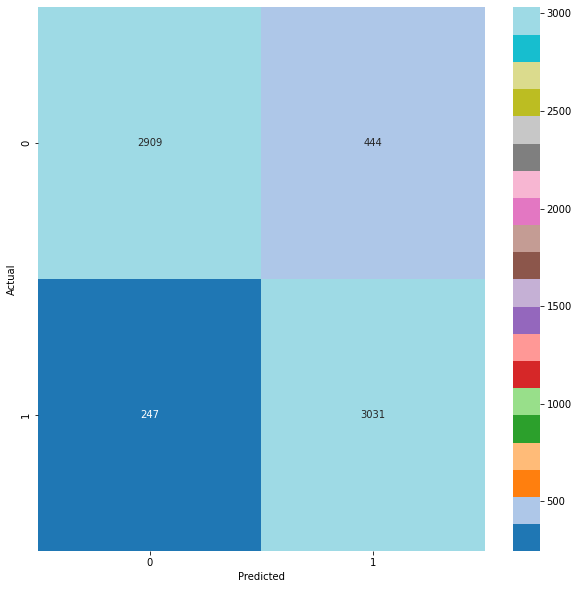

In [19]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [20]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.8958
recall :  0.9246
F1_score :  0.8977
precision :  0.8722


# 5. Save results to Excel file

In [21]:
# define tarjet
newFile = "../results_NB_set2.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #13', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 15

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)